<a href="https://colab.research.google.com/github/mundundan-star/online-retail-customer-analytics/blob/main/6.0%20Predicting_Customer_Life_Time_Value_(CLTV).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, inspect, text
from google.colab import userdata

engine = create_engine(userdata.get('NEON_DATABASE_URL'))

# importing metrics data before august 31st and merging customer spend and frequency after 31st for testing

query = """
WITH train_data AS (
SELECT "CustomerID",
   "Frequency",
   "Recency",
   "TotalRevenue"/"Frequency" AS "AOV",
   "ObservedLifeSpan",
   "Tenure",
   "ProductDiversity"

FROM v_customer_metrics),

test_data AS
(SELECT "CustomerID",
    COUNT(DISTINCT "InvoiceDate") AS "Frequency_test",
    AVG("Revenue") AS "AOV_test"
FROM v_clean_sales_analytics
WHERE "InvoiceDate" > '2011-08-31'
GROUP BY 1),

segments AS
(SELECT "CustomerID",
    "Persona"
FROM customer_segment_labels)

SELECT *
FROM train_data
LEFT JOIN segments
USING("CustomerID")
LEFT JOIN test_data
USING("CustomerID")
"""

df = pd.read_sql(text(query), con = engine).fillna(0)

print("Preview of sql query:")
print(df.isna().sum())
print(df.info())
df.head()

Preview of sql query:
CustomerID          0
Frequency           0
Recency             0
AOV                 0
ObservedLifeSpan    0
Tenure              0
ProductDiversity    0
Persona             0
Frequency_test      0
AOV_test            0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3317 entries, 0 to 3316
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        3317 non-null   float64
 1   Frequency         3317 non-null   int64  
 2   Recency           3317 non-null   int64  
 3   AOV               3317 non-null   float64
 4   ObservedLifeSpan  3317 non-null   int64  
 5   Tenure            3317 non-null   int64  
 6   ProductDiversity  3317 non-null   int64  
 7   Persona           3317 non-null   object 
 8   Frequency_test    3317 non-null   float64
 9   AOV_test          3317 non-null   float64
dtypes: float64(4), int64(5), object(1)
memory usage: 259.3+ KB
None


,CustomerID,Frequency,Recency,AOV,ObservedLifeSpan,Tenure,ProductDiversity,Persona,Frequency_test,AOV_test
0,12346.0,1,325,77183.600000,0,325,1,0,0.0,0.000000
1,12347.0,5,129,4.501387,238,367,82,0,2.0,26.192069
2,12348.0,3,248,17.705238,110,358,22,3,1.0,103.333333
3,12350.0,1,310,19.670588,0,310,17,3,0.0,0.000000
4,12352.0,4,262,10.275066,34,296,26,3,3.0,20.090000


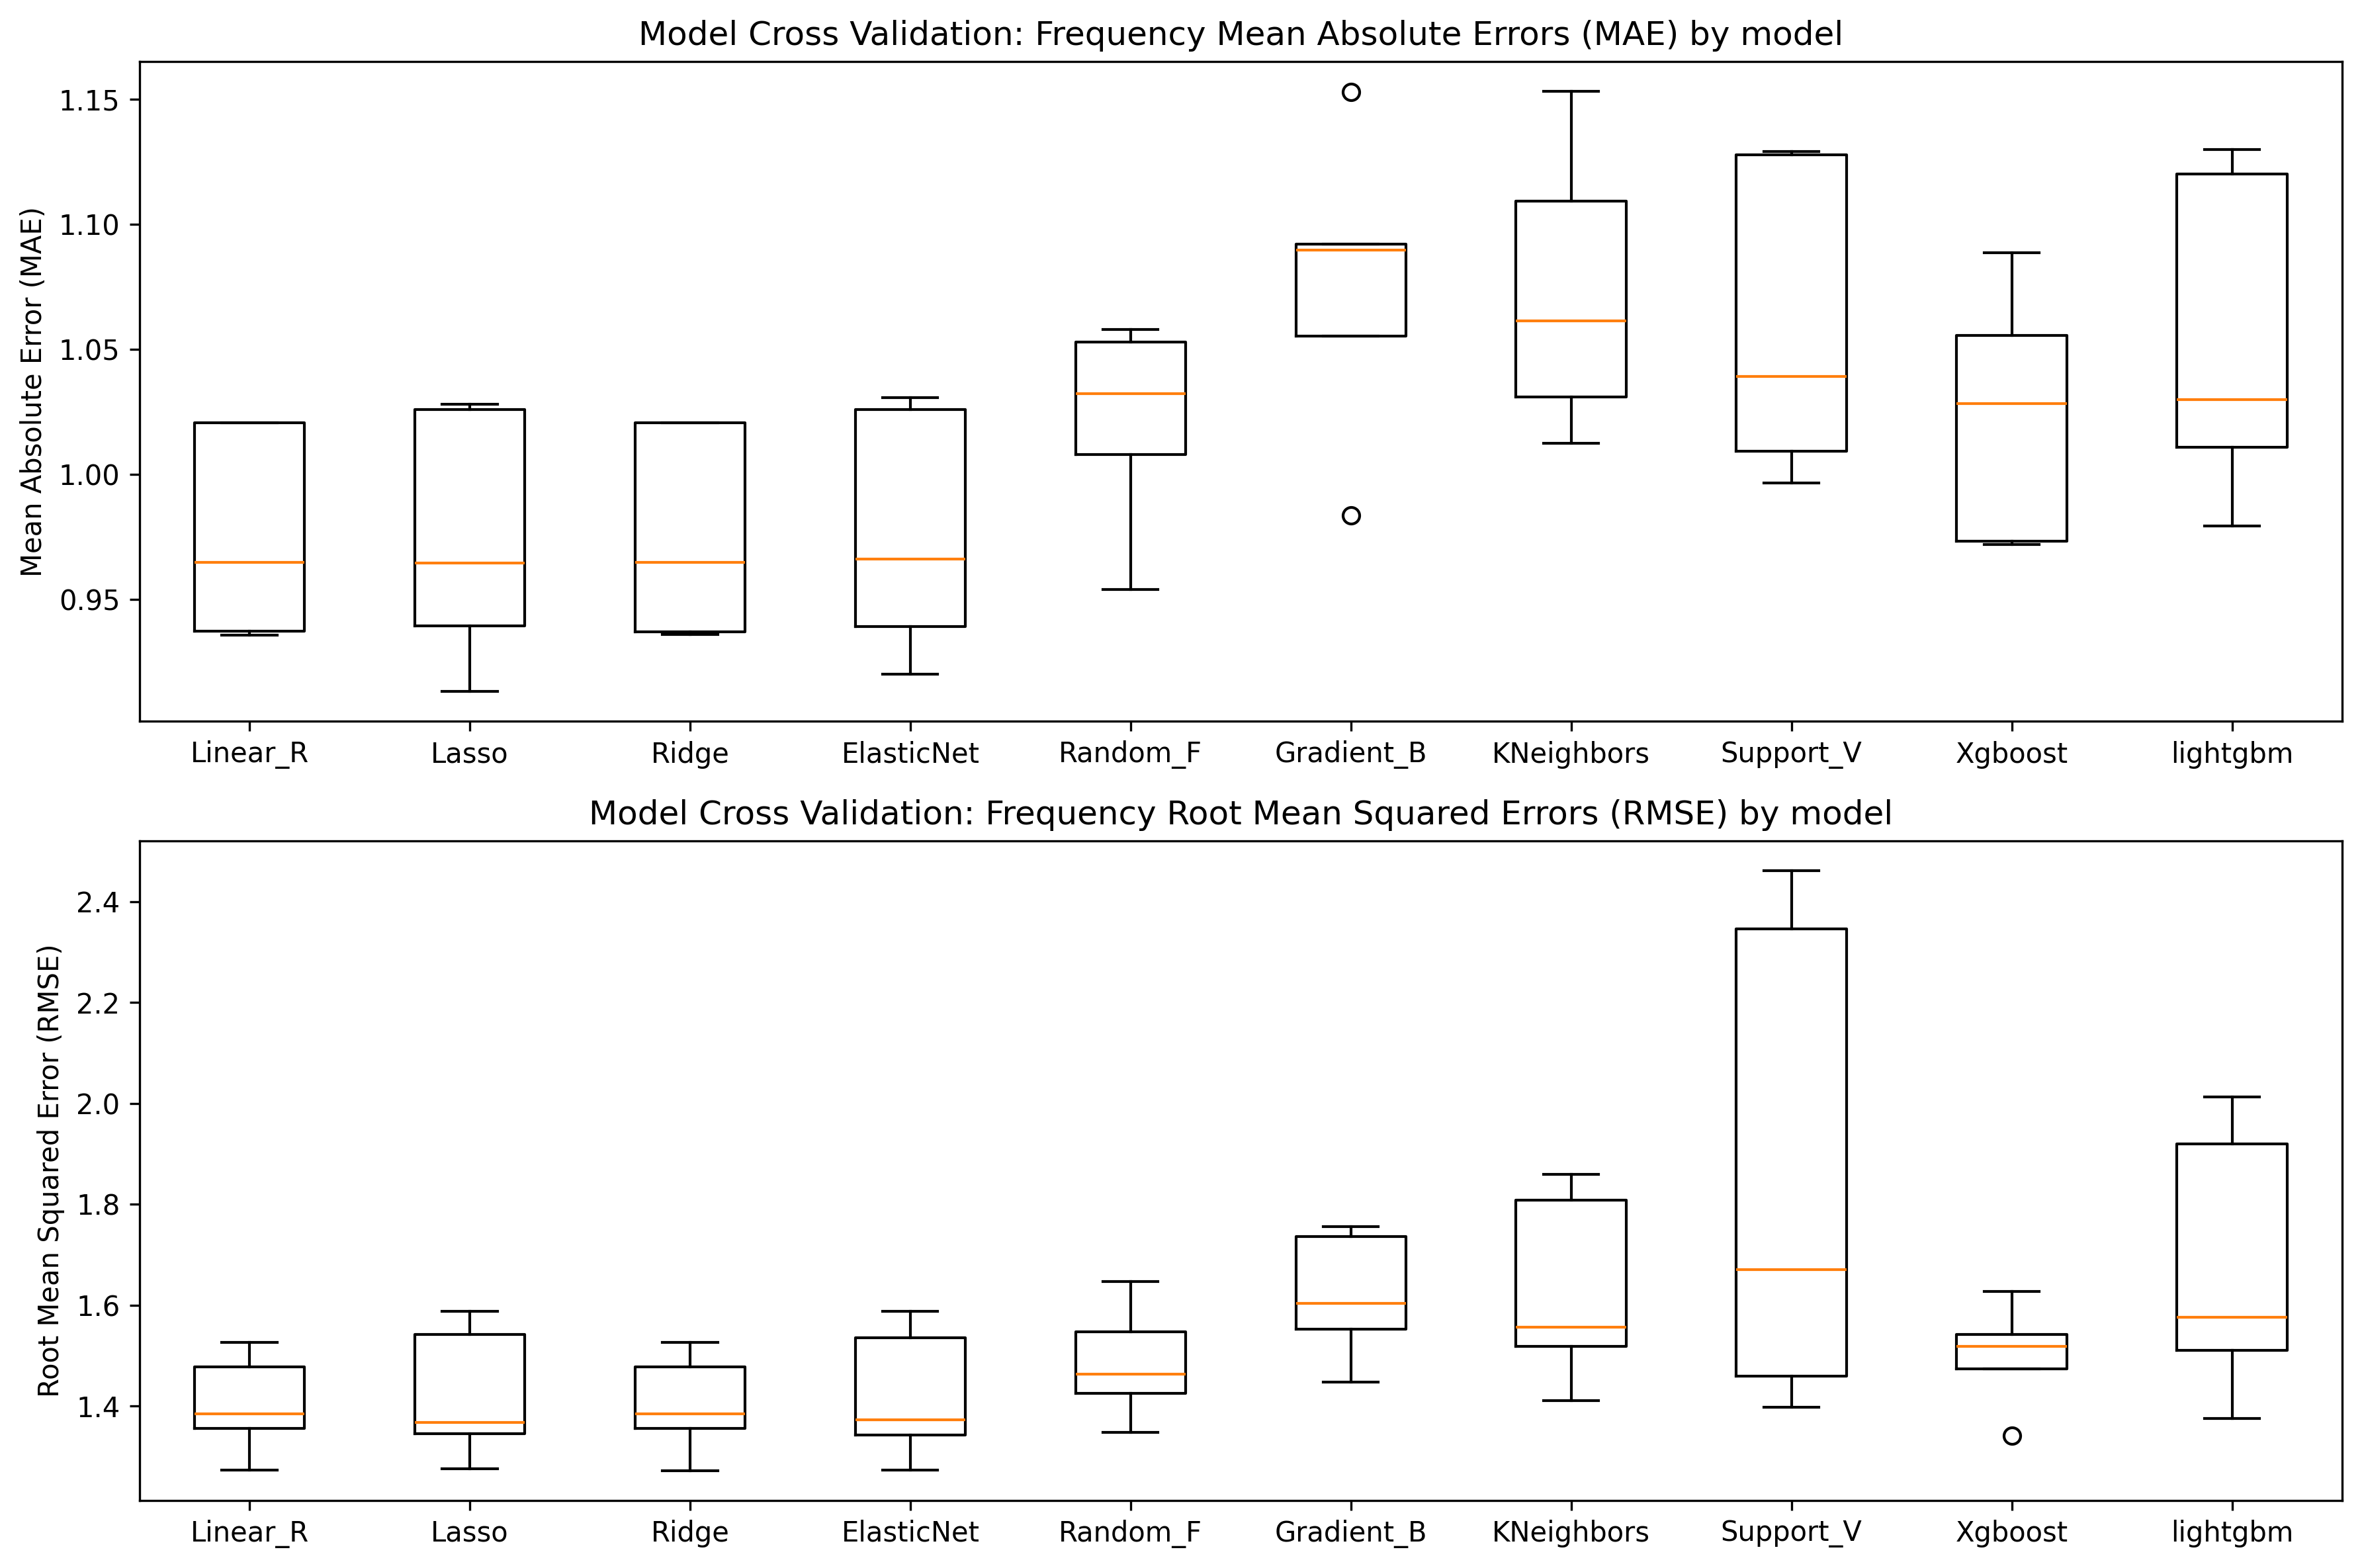

In [3]:

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

X = df.drop(["Frequency_test", "AOV_test", "Persona"], axis=1)
features = X.columns
X = X.values
y = df['Frequency_test']
customer_ids = df['CustomerID'].values

X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(X, y, customer_ids, test_size=0.20, random_state=42)

models = [
    ("Linear_R", LinearRegression()),
    ("Lasso", Lasso(alpha=0.1)),
    ("Ridge", Ridge(alpha=1.0)),
    ("ElasticNet", ElasticNet(alpha=0.1, l1_ratio=0.5)),
    ("Random_F", RandomForestRegressor(n_estimators= 200, max_depth= 20, random_state=42, min_samples_split = 2)),
    ("Gradient_B", GradientBoostingRegressor(n_estimators=300, max_depth=6, random_state=42)),
    ("KNeighbors", KNeighborsRegressor(n_neighbors=5)),
    ("Support_V", SVR(C=10.0, epsilon=1.0)),
    ("Xgboost", XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42)),
    ("lightgbm", LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42, verbose=-1))
]

scaler = StandardScaler()

mae_results = []
rmse_results = []
model_name = []


for name, model in models:
    wrapped_model = TransformedTargetRegressor(
                   regressor = model,
                   func = np.log1p,
                   inverse_func = np.expm1)
    pipeline = make_pipeline(scaler, model)
    kf = KFold(n_splits=5, shuffle=True, random_state= 30)

    mae_scores = cross_val_score(pipeline, X_train, y_train, cv=kf, n_jobs=-1, scoring='neg_mean_absolute_error')
    rmse_scores = cross_val_score(pipeline, X_train, y_train, cv=kf, n_jobs=-1, scoring='neg_root_mean_squared_error')

    mae_results.append(-mae_scores)
    rmse_results.append(-rmse_scores)
    model_name.append(name)

fig, (ax1, ax2) = plt.subplots(2,1, figsize = (12,8), dpi = 300)
ax1.boxplot(mae_results, tick_labels = model_name)
ax1.set_ylabel("Mean Absolute Error (MAE)")
ax1.set_title("Model Cross Validation: Frequency Mean Absolute Errors (MAE) by model")

ax2.boxplot(rmse_results, tick_labels = model_name)
ax2.set_ylabel("Root Mean Squared Error (RMSE)")
ax2.set_title("Model Cross Validation: Frequency Root Mean Squared Errors (RMSE) by model")
plt.tight_layout()
plt.show()

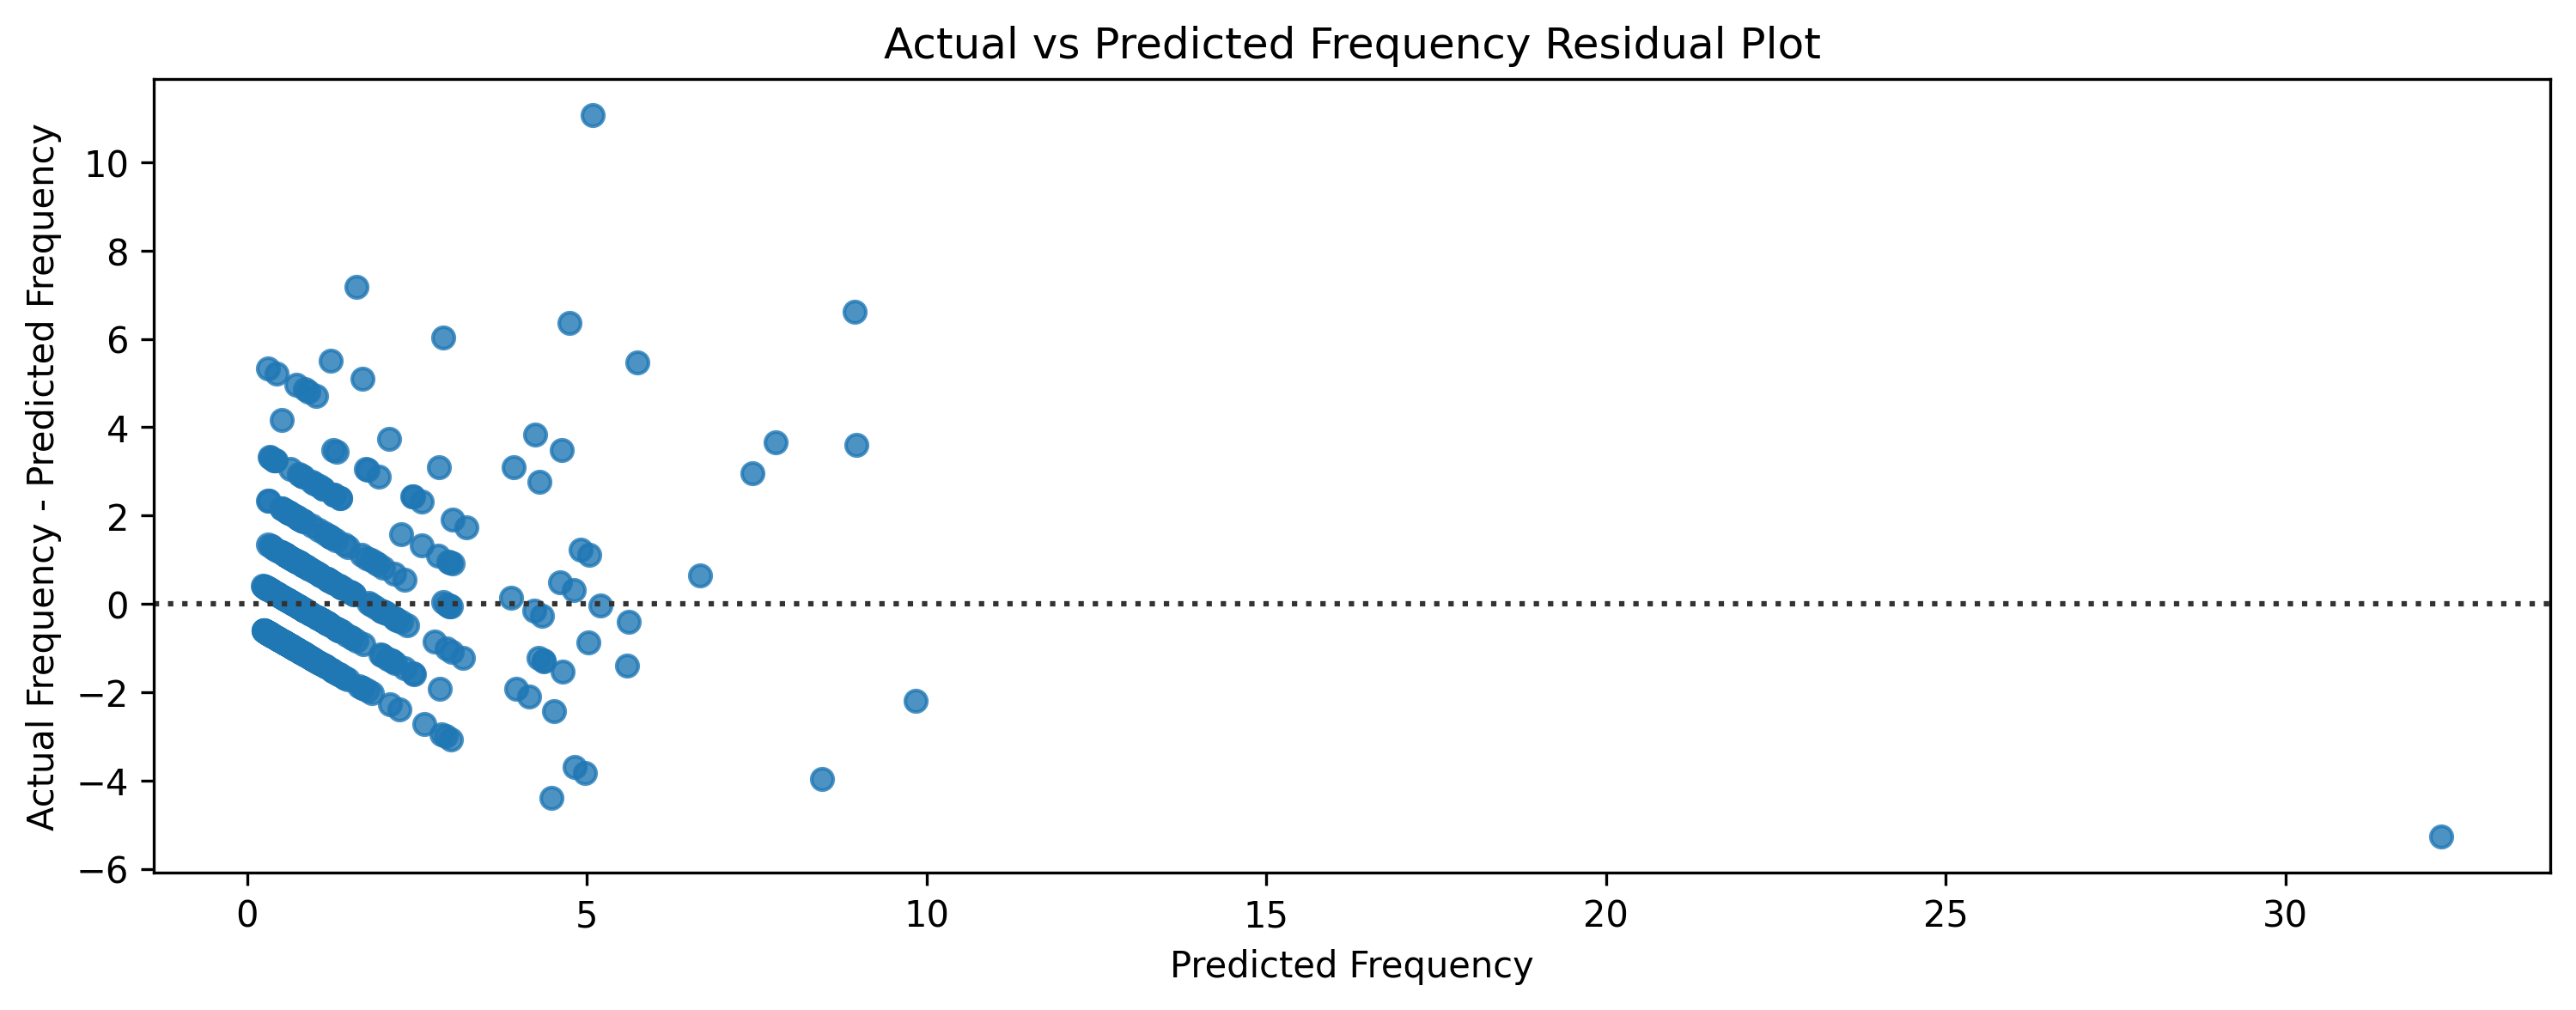

Total Records Evaluated: 664
Test Mean Absolute Error:  1.01
Test Root Mean Squared Error:  1.54


In [4]:
model = RandomForestRegressor(n_estimators = 300, max_depth = 6, min_samples_leaf = 2, random_state = 42)
#model = LinearRegression()

wrapped_model = TransformedTargetRegressor(
regressor = model,
func = np.log1p,
inverse_func = np.expm1)

pipeline = make_pipeline(scaler, wrapped_model)
pipeline.fit(X_train, y_train)

frequency_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, frequency_pred)
rmse= np.sqrt(mean_squared_error(y_test, frequency_pred))

frequency_actual = y_test
freq_residuals = frequency_actual - frequency_pred

plt.figure(figsize = (12,4), dpi = 300)
sns.residplot(x = frequency_pred, y = frequency_actual)
plt.xlabel("Predicted Frequency")
plt.ylabel("Actual Frequency - Predicted Frequency")
plt.title("Actual vs Predicted Frequency Residual Plot")
plt.show()

print(f'Total Records Evaluated: {len(frequency_pred)}')
print(f'Test Mean Absolute Error: {mae: .2f}')
print(f'Test Root Mean Squared Error: {rmse: .2f}')

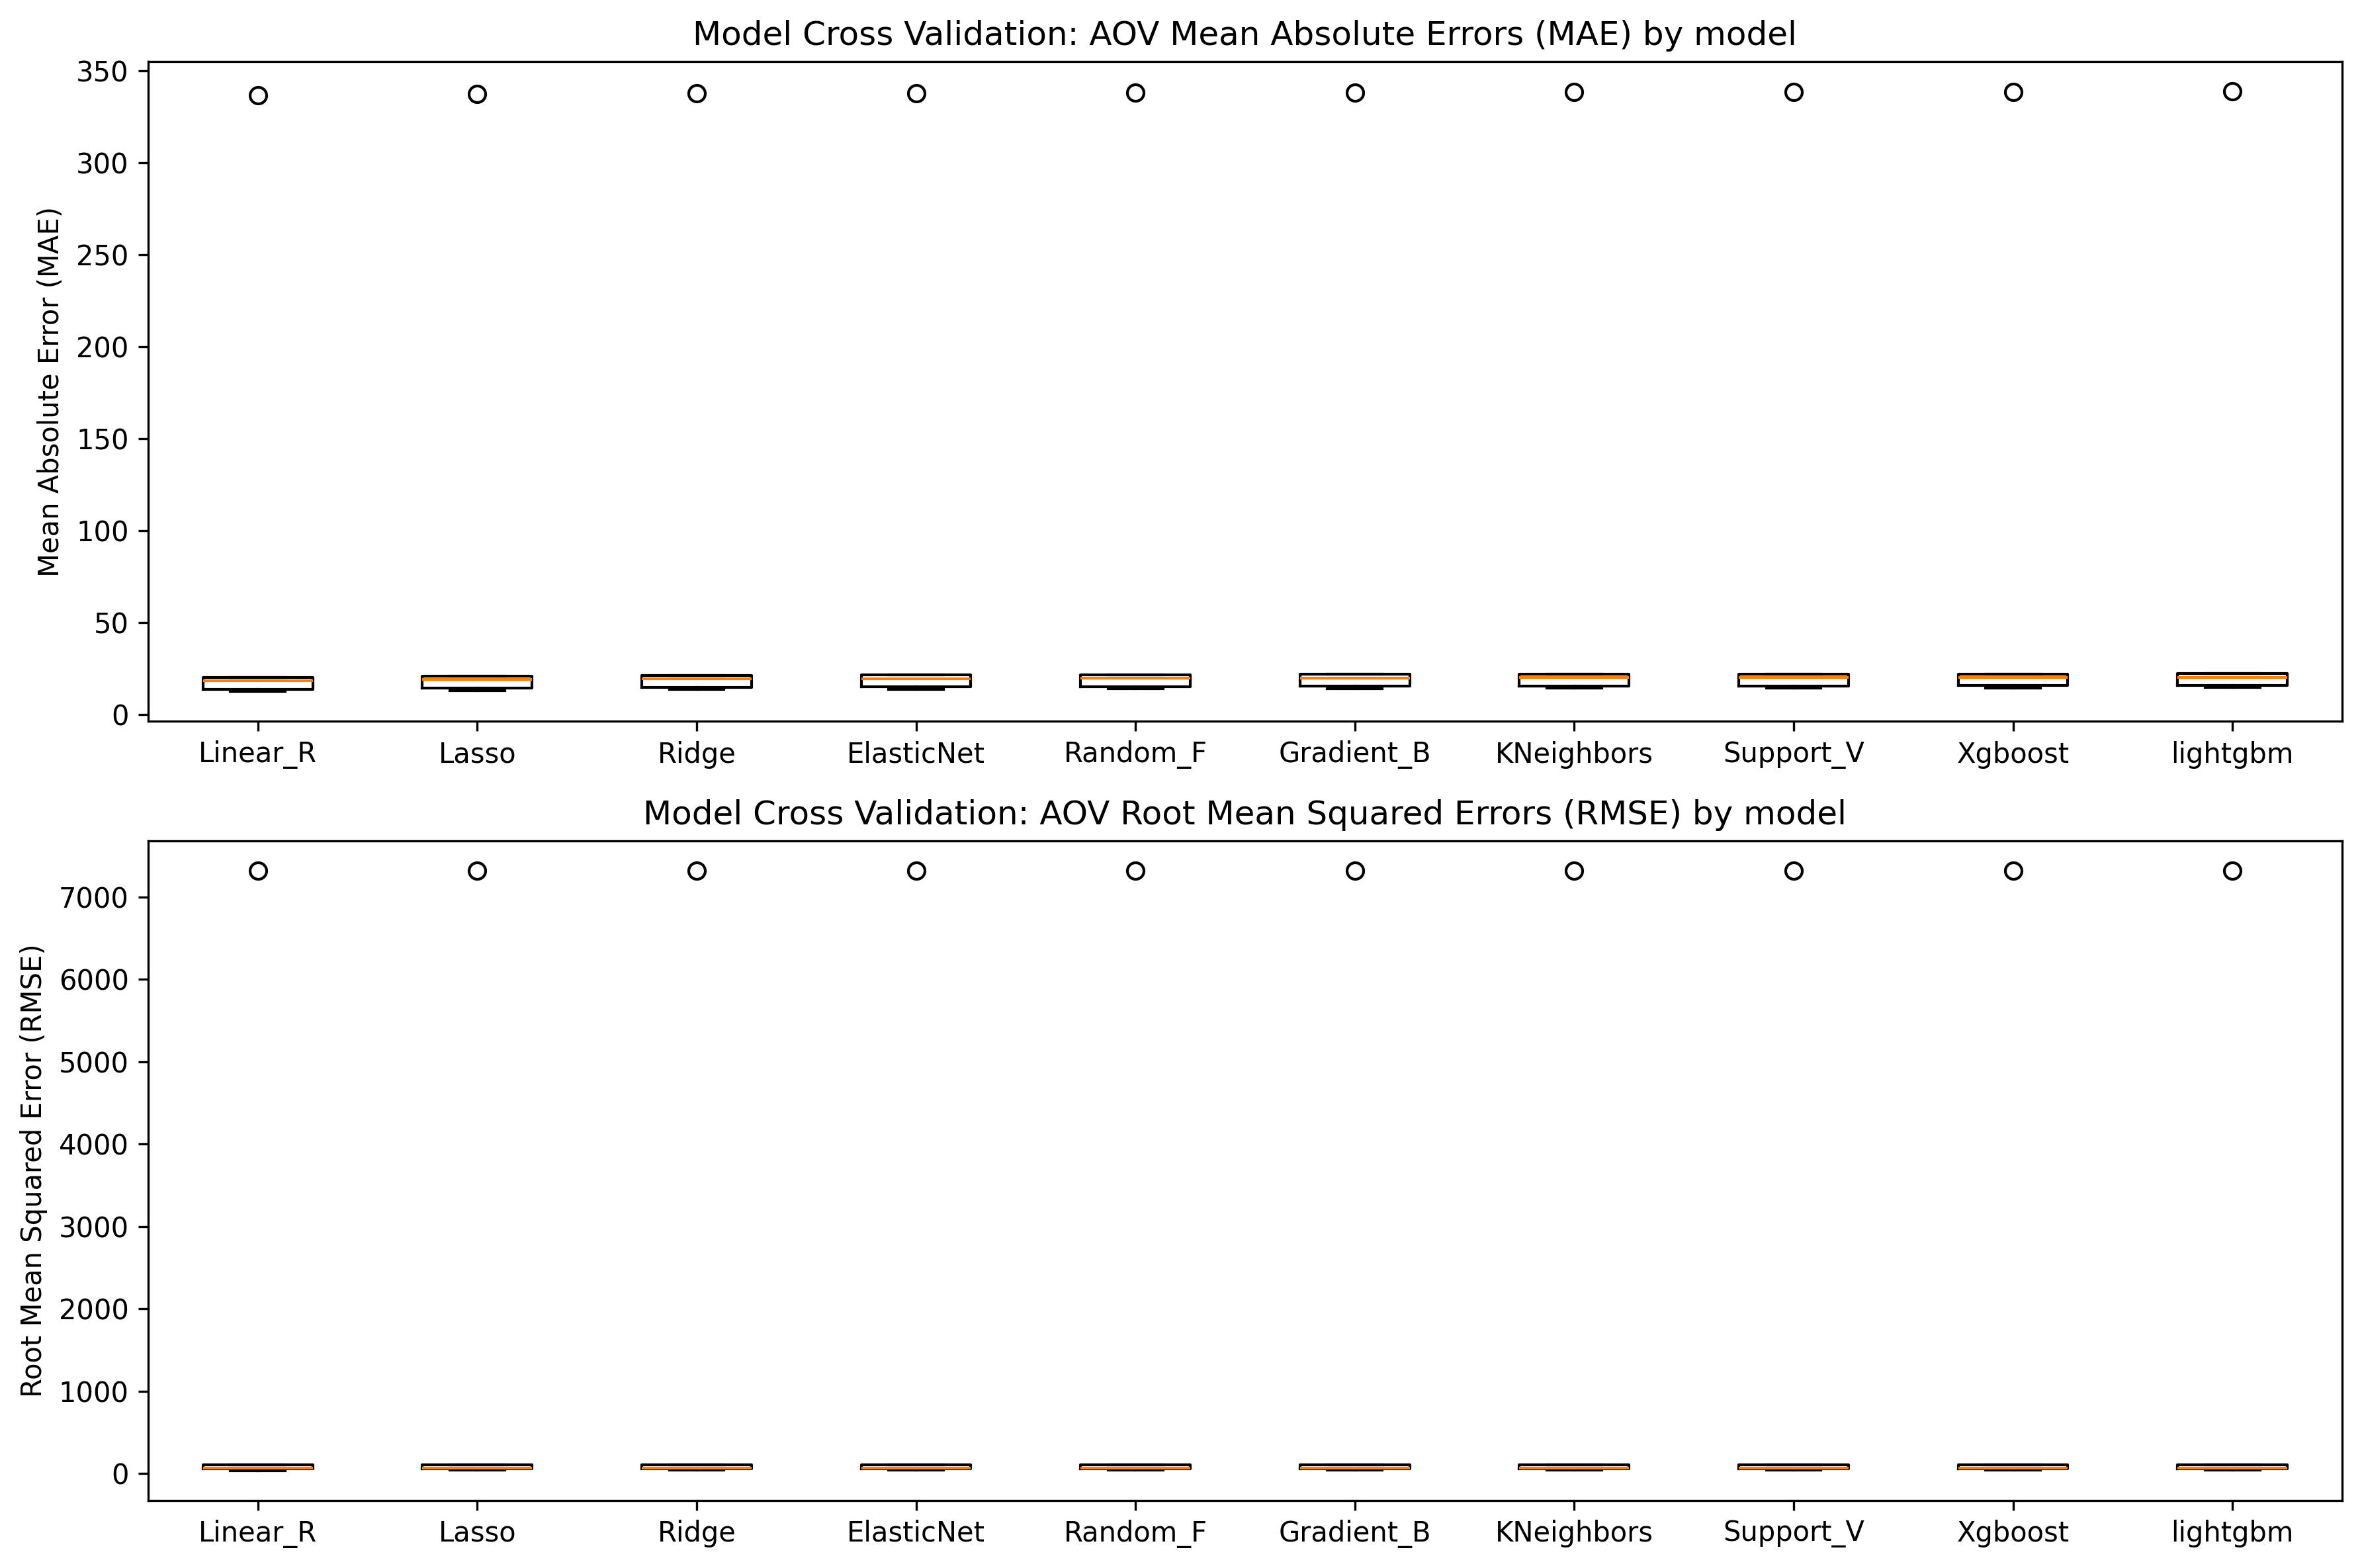

In [5]:
X = df.drop(["Frequency_test", "AOV_test", "Persona"], axis=1)
features = X.columns
X = X.values
y = df['AOV_test']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

scaler = StandardScaler()

mae_results = []
rmse_results = []
model_name = []


for name, model in models:
    wrapped_model = TransformedTargetRegressor(
                   regressor = wrapped_model,
                   func = np.log1p,
                   inverse_func = np.expm1)
    pipeline = make_pipeline(scaler, wrapped_model)
    kf = KFold(n_splits=5, shuffle=True, random_state= 42)

    mae_scores = cross_val_score(pipeline, X_train, y_train, cv=kf, n_jobs=-1, scoring='neg_mean_absolute_error')
    rmse_scores = cross_val_score(pipeline, X_train, y_train, cv=kf, n_jobs=-1, scoring='neg_root_mean_squared_error')

    mae_results.append(-mae_scores)
    rmse_results.append(-rmse_scores)
    model_name.append(name)

fig, (ax1, ax2) = plt.subplots(2,1, figsize = (12,8), dpi = 300)
ax1.boxplot(mae_results, tick_labels = model_name)
ax1.set_ylabel("Mean Absolute Error (MAE)")
ax1.set_title("Model Cross Validation: AOV Mean Absolute Errors (MAE) by model")

ax2.boxplot(rmse_results, tick_labels = model_name)
ax2.set_ylabel("Root Mean Squared Error (RMSE)")
ax2.set_title("Model Cross Validation: AOV Root Mean Squared Errors (RMSE) by model")
plt.tight_layout()
plt.show()

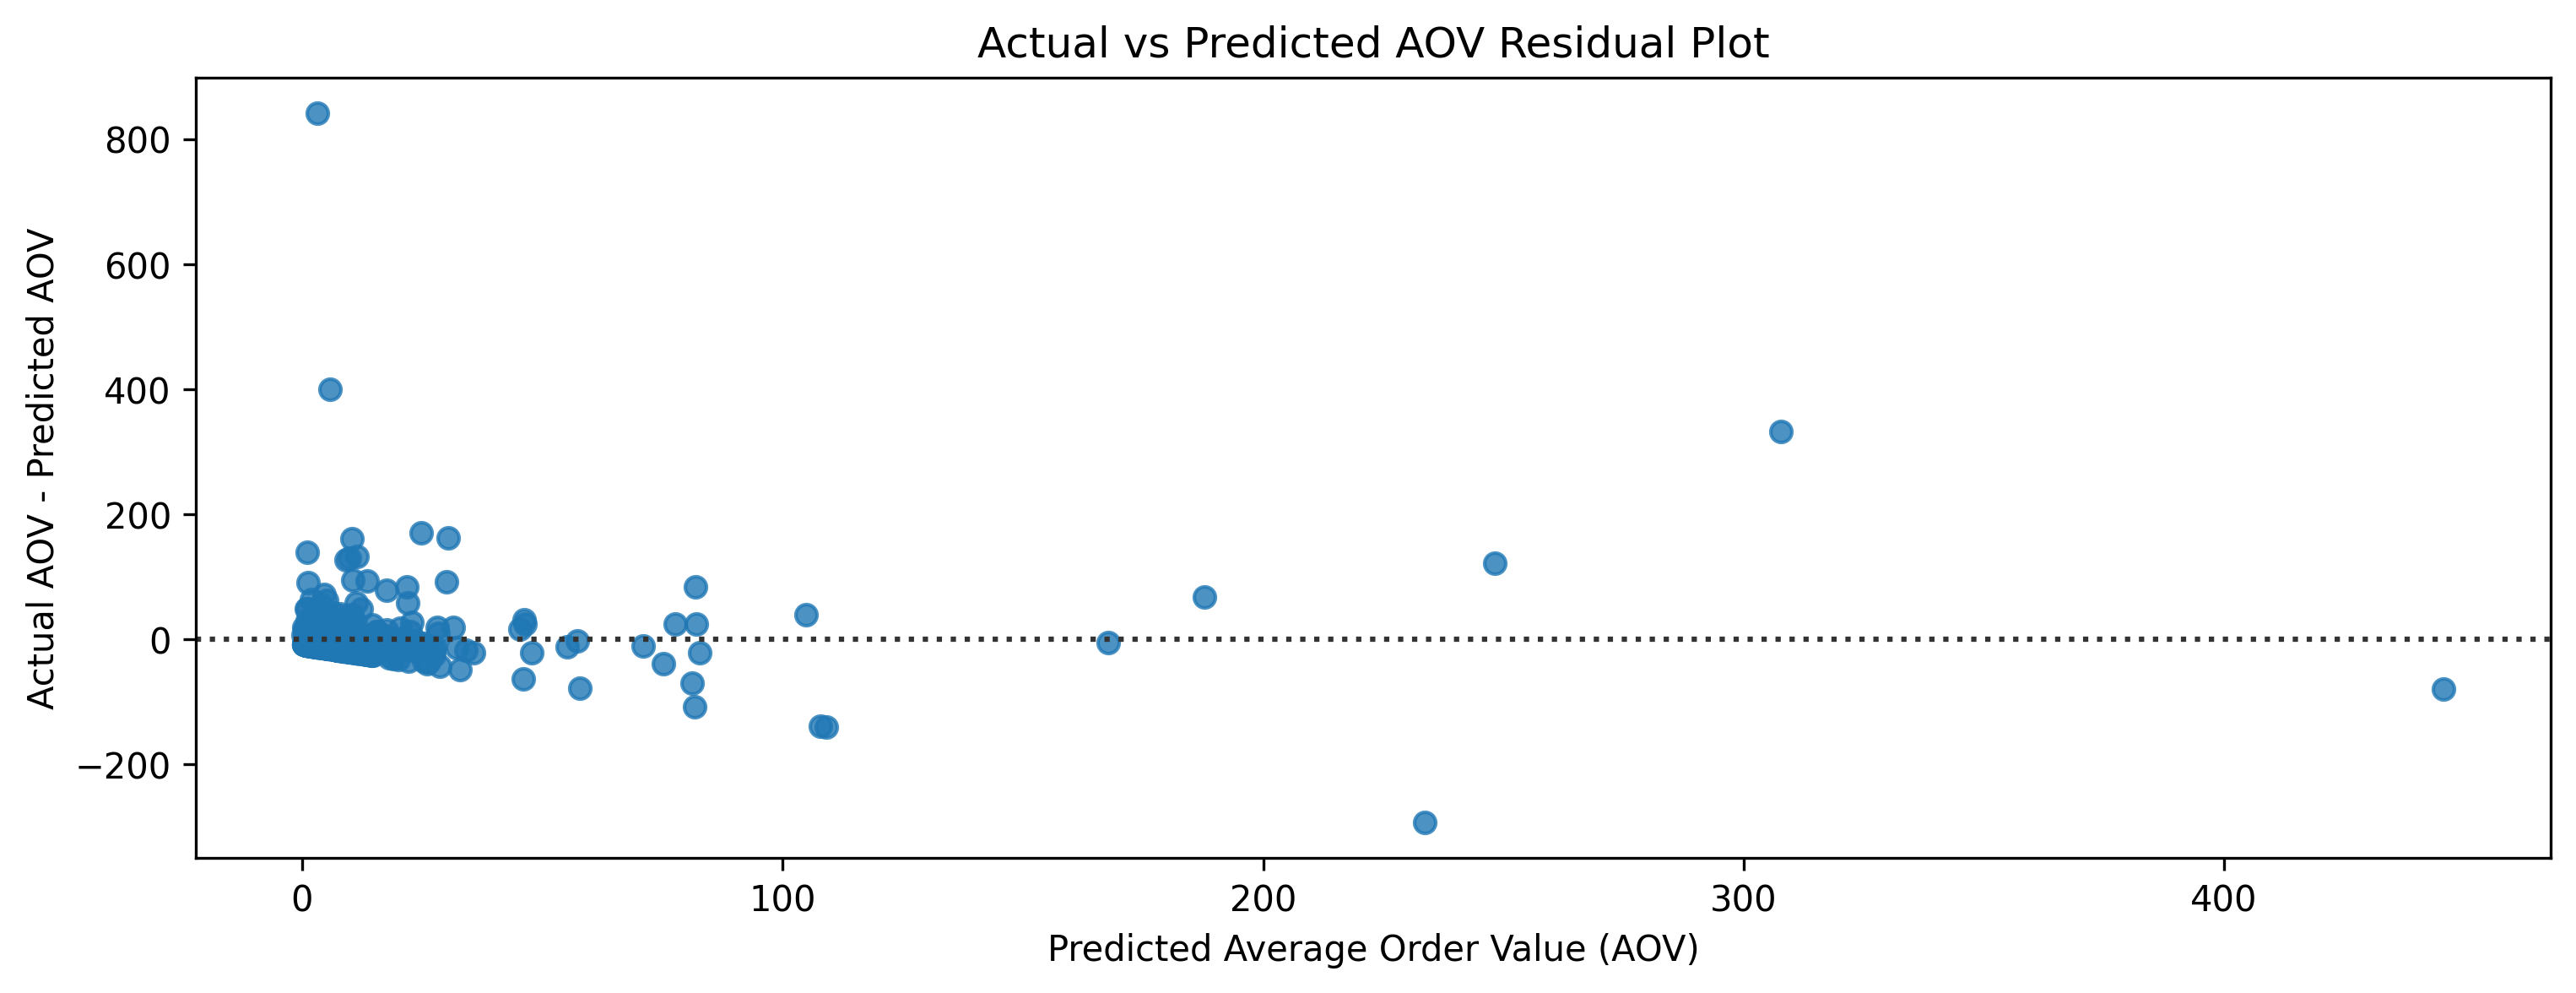

Total Records Evaluated: 664
AOV Test Mean Absolute Error:  16.50
AOV Test Root Mean Squared Error:  49.07


In [6]:
model = RandomForestRegressor(n_estimators = 200, max_depth = 20, min_samples_leaf = 2, random_state = 42)
#model = LinearRegression()

wrapped_model = TransformedTargetRegressor(
regressor = model,
func = np.log1p,
inverse_func = np.expm1)

pipeline = make_pipeline(scaler, wrapped_model)
pipeline.fit(X_train, y_train)

AOV_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, AOV_pred)
rmse= np.sqrt(mean_squared_error(y_test, AOV_pred))

AOV_actual = y_test

plt.figure(figsize = (12,4), dpi = 300)
sns.residplot(x = AOV_pred, y = AOV_actual)
plt.xlabel("Predicted Average Order Value (AOV)")
plt.ylabel("Actual AOV - Predicted AOV")
plt.title("Actual vs Predicted AOV Residual Plot")
plt.show()

print(f'Total Records Evaluated: {len(AOV_pred)}')
print(f'AOV Test Mean Absolute Error: {mae: .2f}')
print(f'AOV Test Root Mean Squared Error: {rmse: .2f}')

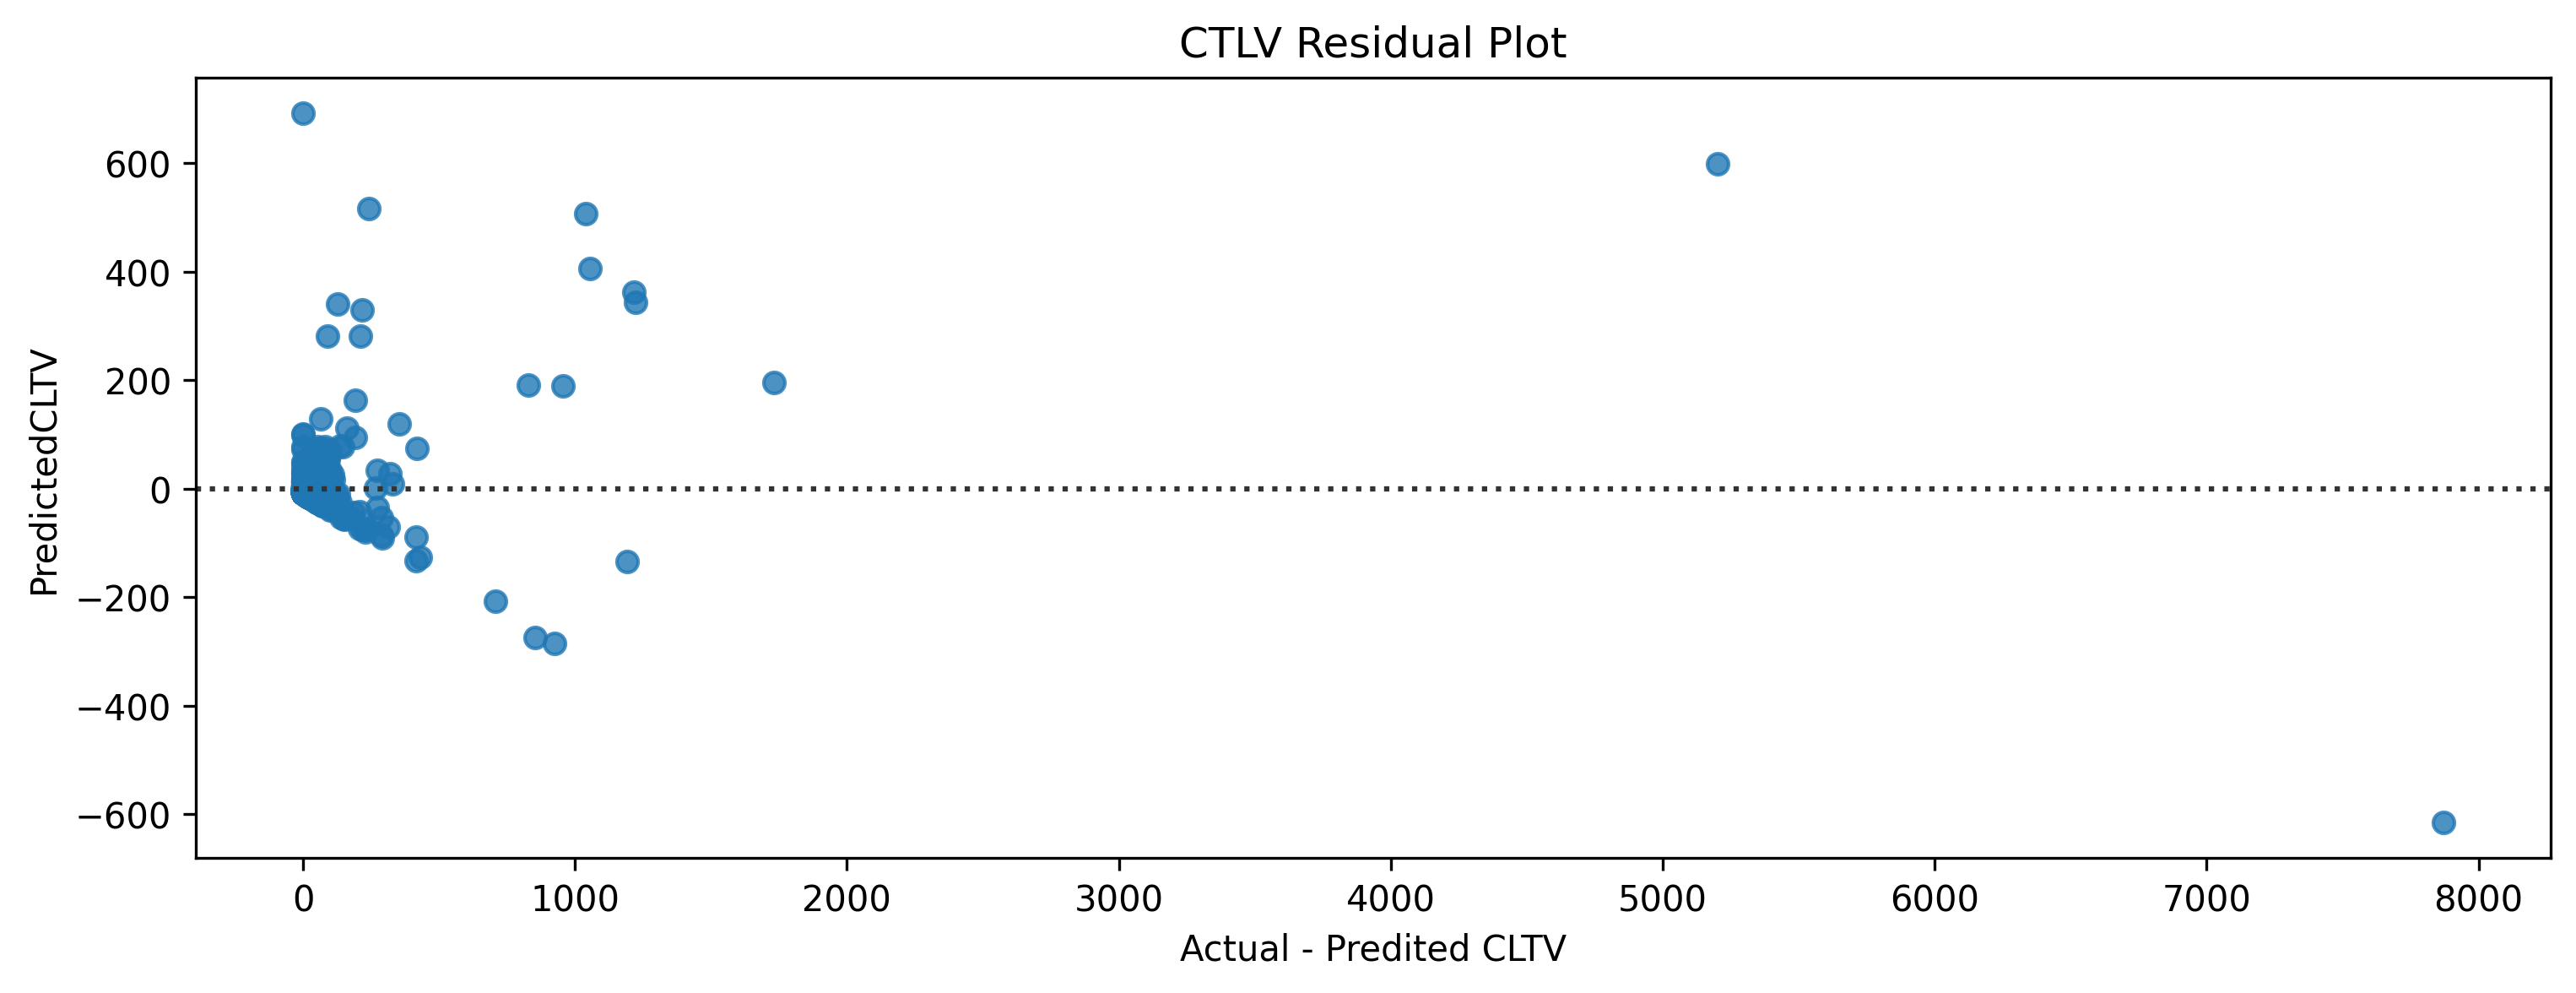


Preview of data exported to Database:


,CustomerID,Persona,ActualFrequency,PredictedFrequency,ActualAOV,PredictedAOV,ActualCLTV,PredictedCLTV
0,17884.0,3,1.0,1.0,4.751364,2.633250,4.751364,2.633250
1,18270.0,3,1.0,0.0,28.533333,4.070267,28.533333,0.000000
2,12732.0,4,0.0,1.0,0.000000,14.435716,0.000000,14.435716
3,16898.0,0,1.0,1.0,3.228621,2.358350,3.228621,2.358350
4,17602.0,0,4.0,1.0,9.420159,3.956148,37.680636,3.956148


In [24]:
cltv_df = pd.DataFrame({
"CustomerID": ids_test,
"ActualFrequency": frequency_actual,
"PredictedFrequency": frequency_pred.round(0),
"ActualAOV": AOV_actual,
"PredictedAOV": AOV_pred
})

cltv_df['ActualCLTV'] = cltv_df['ActualFrequency'] * cltv_df['ActualAOV']
cltv_df['PredictedCLTV'] = cltv_df['PredictedFrequency'] * cltv_df['PredictedAOV']


cltv_df = df[['CustomerID','Persona']].merge(cltv_df, how = 'right', on = 'CustomerID')

plt.figure(figsize = (12,4), dpi = 300)
sns.residplot(data = cltv_df, x = 'ActualCLTV', y ='PredictedCLTV')
plt.xlabel('Actual - Predited CLTV')
plt.title("CTLV Residual Plot")
plt.show()

engine = create_engine(userdata.get("NEON_DATABASE_URL"))

cltv_df.to_sql(
    name = 'cltv_test_predictions',
    con = engine,
    if_exists = 'replace',
    index = False
)



query = """
SELECT *
FROM cltv_test_predictions
LIMIT 5
"""


print("\nPreview of data exported to Database:")
df = pd.read_sql(text(query), con = engine)
df